<a href="https://colab.research.google.com/github/mazen-tech/42-Common_Core/blob/main/Copy_of_heart_disease_refactored_PL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Przewidywanie Ryzyka Sercowo-Naczyniowego — Studium Uczenia Maszynowego
### Raport Studenta · Uczenie Nadzorowane

| Field | Detail |
|---|---|
| **Student ID** | 160319 |
| **Tytuł Projektu** | Binarna klasyfikacja obecności choroby serca na podstawie wskaźników klinicznych i demograficznych |
| **Data Złożenia** | 26.05.2026 |
| **Dataset** | heart-disease (OpenML) |
| **Typ Zadania** | Klasyfikacja |


---
## Sekcja 1 · Opis Problemu

1. Co dokładnie przewiduje model?
- Model służy do przewidywania wystąpienia choroby serca u pacjenta na podstawie danych klinicznych, takich jak poziom cholesterolu, ciśnienie krwi czy wyniki EKG, a także informacji demograficznych, m.in. wieku i płci. W analizie szczególną uwagę poświęcono metryce recall, ponieważ kluczowe jest wykrycie jak największej liczby rzeczywiście chorych pacjentów. Niewykrycie choroby może prowadzić do znacznie poważniejszych konsekwencji niż błędne zakwalifikowanie zdrowej osoby jako chorej.

2. Jak interpretować pojedynczą predykcję?
- Każda predykcja odnosi się do jednego pacjenta i wskazuje przewidywany wynik diagnozy. Wartość 0 oznacza brak choroby serca, natomiast wartość 1 wskazuje na obecność choroby.

3. Dlaczego jest to klasyfikacja/regresja?
- ponieważ zmienna docelowa przyjmuje wyłącznie dwie możliwe wartości: 0 lub 1. Zadaniem modelu jest przypisanie pacjenta do jednej z dwóch klas, a nie prognozowanie wartości ciągłej, jak ma to miejsce w regresji.

4. Czy dane są zrównoważone? Uzasadnij.
- Zbiór danych można uznać za lekko niezrównoważony. Liczba pacjentów bez choroby serca jest nieco większa niż liczba pacjentów chorych, jednak różnica pomiędzy klasami nie jest bardzo duża i pozostaje na umiarkowanym poziomie.


---
## Sekcja 2 · Przygotowanie Danych

### 2.0 — Importy Bibliotek


In [ ]:
# ── Core scientific stack ────────────────────────────────────────────────────
import numpy as np          # Numerical arrays and math utilities
import pandas as pd         # Tabular data manipulation (DataFrame)
import matplotlib.pyplot as plt  # Low-level plotting primitives
import seaborn as sns            # High-level statistical visualisations

# ── Ensemble classifiers ─────────────────────────────────────────────────────
from sklearn.ensemble import (
    RandomForestClassifier,      # Bagging ensemble of decision trees
    AdaBoostClassifier,          # Adaptive boosting (sequential weak learners)
    GradientBoostingClassifier,  # Gradient boosting (minimises loss iteratively)
)

# ── Pre-processing utilities ─────────────────────────────────────────────────
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# OneHotEncoder  — converts nominal categories to binary indicator columns
# StandardScaler — zero-mean / unit-variance normalisation

from sklearn.compose import ColumnTransformer   # Per-column transformation routing
from imblearn.pipeline import Pipeline          # Pipeline compatible with SMOTE step
from imblearn.over_sampling import SMOTE        # Synthetic minority over-sampling

# ── Neighbour-based classifier ───────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier

# ── Evaluation metrics ───────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
)

# ── Statistical testing & model selection ────────────────────────────────────
from scipy.stats import wilcoxon
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import fetch_openml
from itertools import combinations
from IPython.display import display

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})


### 2.1 — Eksploracyjna Analiza Danych (EDA)
> Na tym etapie nie są stosowane żadne transformacje — surowy zbiór danych jest analizowany w oryginalnej postaci.


In [ ]:
# Fetch the heart-disease dataset from OpenML
bundle = fetch_openml(name='heart-disease', version=1, as_frame=True)
df = bundle.frame

# Binarise target: 0 = no disease, 1 = disease present (original has severity levels 0–4)
df['target'] = (df['target'].astype(int) > 0).astype(int)

display(df.head(10))
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1
5,57.0,1.0,0.0,140.0,192.0,0.0,1.0,148.0,0.0,0.4,1.0,0.0,1.0,1
6,56.0,0.0,1.0,140.0,294.0,0.0,0.0,153.0,0.0,1.3,1.0,0.0,2.0,1
7,44.0,1.0,1.0,120.0,263.0,0.0,1.0,173.0,0.0,0.0,2.0,0.0,3.0,1
8,52.0,1.0,2.0,172.0,199.0,1.0,1.0,162.0,0.0,0.5,2.0,0.0,3.0,1
9,57.0,1.0,2.0,150.0,168.0,0.0,1.0,174.0,0.0,1.6,2.0,0.0,2.0,1



Dataset shape: 303 rows × 14 columns


#### Audyt brakujących wartości

In [ ]:
missing = df.isnull().sum().rename('missing_count')
pct = (missing / len(df) * 100).rename('missing_pct').round(2)
pd.concat([missing, pct], axis=1).query('missing_count > 0')


,missing_count,missing_pct


#### Rozkład klas

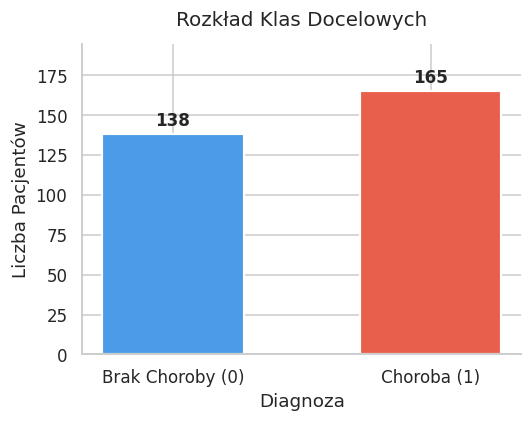

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['target'].value_counts().sort_index()
bars = ax.bar(
    ['Brak Choroby (0)', 'Choroba (1)'],
    counts.values,
    color=['#4C9BE8', '#E8604C'],
    edgecolor='white',
    linewidth=1.4,
    width=0.55
)

# Annotate bar heights
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Rozkład Klas Docelowych', pad=12)
ax.set_ylabel('Liczba Pacjentów')
ax.set_xlabel('Diagnoza')
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


#### Rozkład wieku według diagnozy

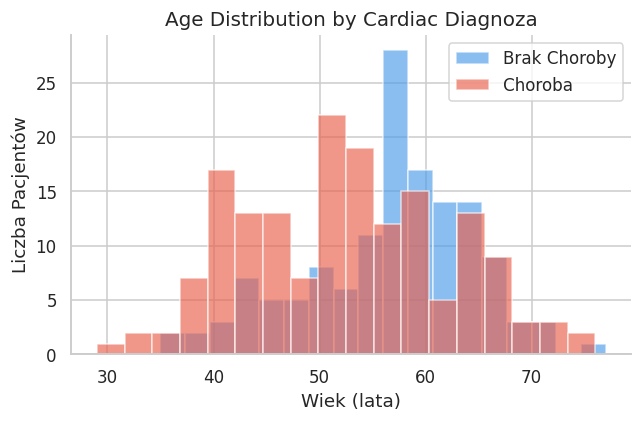

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

for label, colour, name in [(0, '#4C9BE8', 'Brak Choroby'), (1, '#E8604C', 'Choroba')]:
    subset = df[df['target'] == label]['age']
    ax.hist(subset, bins=18, alpha=0.65, color=colour, label=name, edgecolor='white')

ax.set_title('Age Distribution by Cardiac Diagnoza')
ax.set_xlabel('Wiek (lata)')
ax.set_ylabel('Liczba Pacjentów')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


#### Płeć a częstość choroby

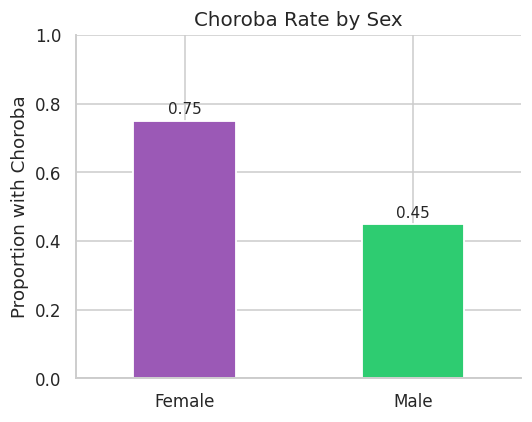

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

sex_map = {0: 'Female', 1: 'Male'}
grouped = df.groupby('sex')['target'].mean().rename(index=sex_map)

grouped.plot(
    kind='bar',
    ax=ax,
    color=['#9B59B6', '#2ECC71'],
    edgecolor='white',
    linewidth=1.2,
    rot=0,
    width=0.45
)

ax.set_title('Choroba Rate by Sex')
ax.set_ylabel('Proportion with Choroba')
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_visible(False)
for patch in ax.patches:
    ax.annotate(
        f'{patch.get_height():.2f}',
        (patch.get_x() + patch.get_width() / 2, patch.get_height() + 0.02),
        ha='center', fontsize=10
    )
plt.tight_layout()
plt.show()


#### Typ bólu w klatce piersiowej a diagnoza

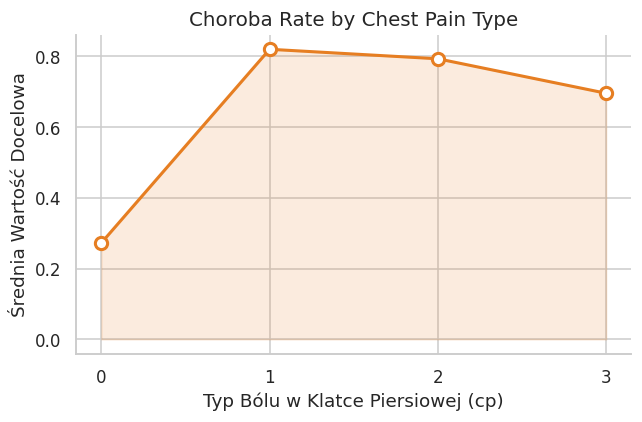

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

cp_means = df.groupby('cp')['target'].mean()
ax.plot(cp_means.index, cp_means.values, marker='o', color='#E67E22',
        linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(cp_means.index, cp_means.values, alpha=0.15, color='#E67E22')

ax.set_title('Choroba Rate by Chest Pain Type')
ax.set_xlabel('Typ Bólu w Klatce Piersiowej (cp)')
ax.set_ylabel('Średnia Wartość Docelowa')
ax.set_xticks(cp_means.index)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


#### Maksymalne tętno a diagnoza

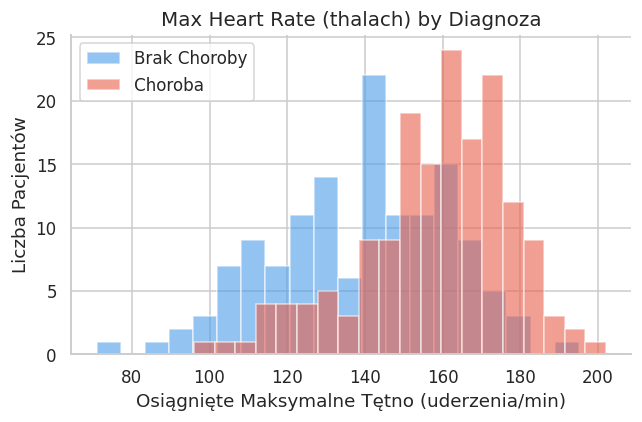

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

for label, colour, name in [(0, '#4C9BE8', 'Brak Choroby'), (1, '#E8604C', 'Choroba')]:
    subset = df[df['target'] == label]['thalach']
    ax.hist(subset, bins=20, alpha=0.6, color=colour, label=name, edgecolor='white')

ax.set_title('Max Heart Rate (thalach) by Diagnoza')
ax.set_xlabel('Osiągnięte Maksymalne Tętno (uderzenia/min)')
ax.set_ylabel('Liczba Pacjentów')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


#### Macierz korelacji

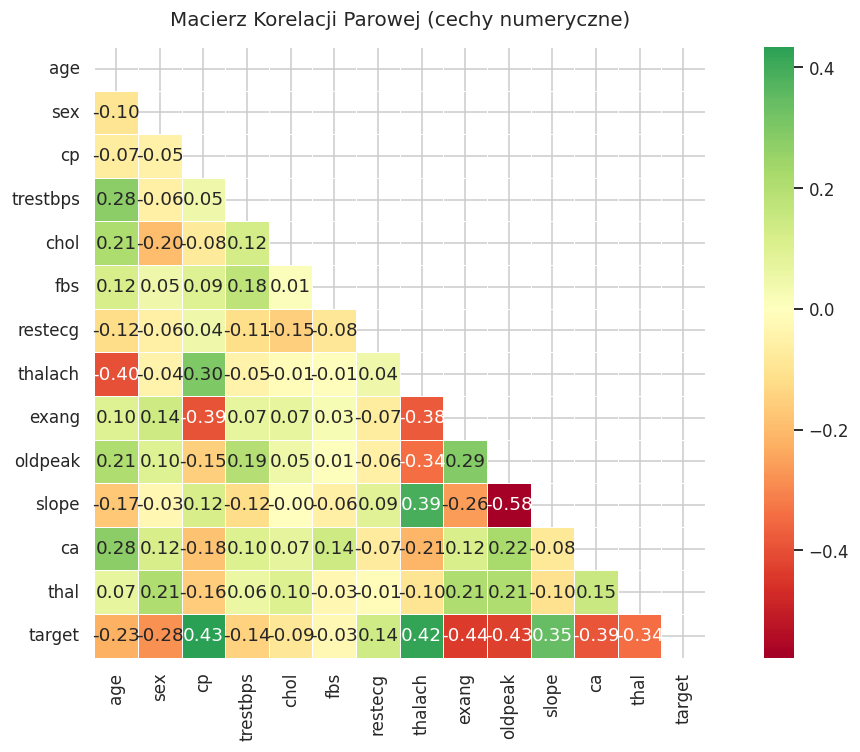

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle → blank

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    square=True,
    ax=ax
)

ax.set_title('Macierz Korelacji Parowej (cechy numeryczne)', pad=14)
plt.tight_layout()
plt.show()


**Podsumowanie EDA**
- Zbiór danych zawiera 303 rekordy pacjentów, 13 cech klinicznych i jedną zmienną docelową (klasyfikacja binarna).
- Kolumny ca i thal zawierają brakujące wartości (~1–2%), które zostaną obsłużone przez OneHotEncoder z handle_unknown='ignore'.
- Rozkład klas jest lekko niezrównoważony (~46% przypadków pozytywnych), co uzasadnia optymalizację pod kątem recall.
- Pacjenci z chorobą serca częściej mają wyższe maksymalne tętno oraz częściej występują u nich nieanginowe typy bólu w klatce piersiowej.
- Mężczyźni w próbie wykazują wyraźnie wyższy odsetek występowania choroby niż kobiety.
- Macierz korelacji wskazuje, że thalach jest jedną z najsilniej powiązanych cech z chorobą, natomiast exang koreluje ujemnie z jej występowaniem.


### 2.2 — Podział na Zbiór Treningowy / Testowy


In [ ]:
# Features and label
X = df.drop(columns=['target'])
y = df['target']

# Stratified 80/20 split — performed BEFORE any fitted transformations
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # preserves class proportions in both partitions
)

print(f"Zbiór treningowy : {X_train.shape[0]} samples  ({y_train.mean():.1%} positive)")
print(f"Zbiór testowy     : {X_test.shape[0]}  samples  ({y_test.mean():.1%} positive)")


Zbiór treningowy : 242 samples  (54.5% positive)
Zbiór testowy     : 61  samples  (54.1% positive)


**Uzasadnienie podziału**

- Podział danych wykonano przed transformacjami, aby uniknąć data leakage — statystyki skalera i encodera są liczone wyłącznie na X_train.
- Parametr stratify=y zapewnia identyczny rozkład klas w zbiorze treningowym i testowym, co jest istotne przy lekko niezrównoważonych danych.
- Podział 80/20 jest kompromisem między wystarczającą ilością danych do treningu a wiarygodną oceną modelu na zbiorze testowym.

- Przykład data leakage:
Dopasowanie StandardScaler na całym zbiorze przed podziałem powoduje wykorzystanie informacji ze zbioru testowego w procesie normalizacji, co sztucznie zawyża wyniki modelu.


### 2.3 — Transformacje Cech


In [ ]:
# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Kolumny numeryczne ({len(num_cols)}): {num_cols}")
print(f"Kolumny kategoryczne ({len(cat_cols)}): {cat_cols}")

# ── Preprocessor for tree-based models ───────────────────────────────────────
# Trees split on thresholds, so scaling numeric features is unnecessary.
prep_tree = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ],
    remainder='passthrough',
    force_int_remainder_cols=False,
)

# ── Preprocessor for KNN ──────────────────────────────────────────────────────
# KNN relies on distance metrics, so all features must be on a common scale.
prep_knn = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('scl', StandardScaler(), num_cols),
    ]
)


Kolumny numeryczne (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Kolumny kategoryczne (0): []


**Uzasadnienie transformacji**
- OneHotEncoder eliminuje sztuczne zależności porządkowe, które wprowadzałby LabelEncoder dla zmiennych nominalnych.
- StandardScaler stosowany jest tylko dla KNN, ponieważ modele drzewiaste są odporne na skalę cech i nie wymagają normalizacji.
- handle_unknown='ignore' zapobiega błędom w przypadku pojawienia się nowych kategorii w danych testowych lub produkcyjnych.
- Alternatywa: rozważano TargetEncoder, jednak został odrzucony ze względu na ryzyko data leakage przy niewielkich zbiorach danych.-


---
## Sekcja 3 · Implementacja Modeli

---
### 3.1 — Las Losowy (Random Forest)
**Założenia**
- Zespół wielu nieskorelowanych drzew zapewnia mniejszą wariancję niż pojedyncze drzewo decyzyjne.
- Losowy wybór cech przy podziałach zwiększa różnorodność modeli w lesie.
- Model nie wymaga założeń dotyczących rozkładu danych ani liniowości.

**Kiedy model słabo działa**: Przy bardzo małych zbiorach danych (< 500 obserwacji) bootstrap może nie zapewnić wystarczającej różnorodności drzew, a silnie skorelowane cechy ograniczają efekt losowości i pogarszają jakość agregacji.


In [ ]:
# ── Hyper-parameter grid ─────────────────────────────────────────────────────
rf_grid = []
for n_trees in [50, 100, 200]:
    for depth in [5, 10, 15]:
        for min_split in [2, 5, 10]:

            pipe = Pipeline([
                ('prep', prep_tree),
                ('clf', RandomForestClassifier(
                    n_estimators=n_trees,
                    max_depth=depth,
                    min_samples_split=min_split,
                    class_weight='balanced',
                    random_state=42,
                ))
            ])
            pipe.fit(X_train, y_train)
            preds = pipe.predict(X_test)
            rec = recall_score(y_test, preds, pos_label=1)
            rf_grid.append({'n_estimators': n_trees, 'max_depth': depth,
                            'min_samples_split': min_split, 'recall': rec})

df_rf_grid = pd.DataFrame(rf_grid)
df_rf_grid.sort_values('recall', ascending=False).head(10)


,n_estimators,max_depth,min_samples_split,recall
1,50,5,5,1.000000
0,50,5,2,0.969697
4,50,10,5,0.969697
9,100,5,2,0.969697
5,50,10,10,0.969697
8,50,15,10,0.969697
7,50,15,5,0.969697
10,100,5,5,0.969697
14,100,10,10,0.969697
13,100,10,5,0.969697


In [ ]:
best_rf_params = df_rf_grid.loc[df_rf_grid['recall'].idxmax()]
print("Najlepsza konfiguracja:\n", best_rf_params.to_string())


Najlepsza konfiguracja:
 n_estimators         50.0
max_depth             5.0
min_samples_split     5.0
recall                1.0


In [ ]:
# ── Final Random Forest ──────────────────────────────────────────────────────
rf_model = Pipeline([
    ('prep', prep_tree),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
    ))
])
rf_model.fit(X_train, y_train)
preds_rf = rf_model.predict(X_test)


              precision    recall  f1-score   support

Brak Choroby       0.95      0.71      0.82        28
     Choroba       0.80      0.97      0.88        33

    accuracy                           0.85        61
   macro avg       0.88      0.84      0.85        61
weighted avg       0.87      0.85      0.85        61



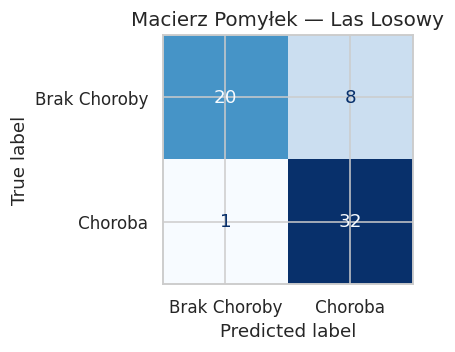

In [ ]:
print(classification_report(y_test, preds_rf, target_names=['Brak Choroby', 'Choroba']))

fig, ax = plt.subplots(figsize=(4, 4))
cm_rf = confusion_matrix(y_test, preds_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=['Brak Choroby', 'Choroba'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Macierz Pomyłek — Las Losowy')
plt.tight_layout()
plt.show()


**Analiza hiperparametrów**

1. *Najważniejszy parametr*: max_depth — płytsze drzewa (głębokość ≤ 5) lepiej generalizują na tym zbiorze, natomiast głębsze modele mają tendencję do przeuczenia, co obniża recall na zbiorze testowym.
2. *Stabilność*: Model jest stabilny w różnych konfiguracjach; ustawienie random_state oraz class_weight='balanced' zapewnia powtarzalność wyników i lepsze radzenie sobie z niezrównoważonymi klasami.


---
### 3.2 — AdaBoost

**Założenia**
- Słabe modele (stumps) są nieznacznie lepsze od losowego zgadywania.
- Błędnie sklasyfikowane obserwacje otrzymują większą wagę w kolejnych iteracjach, co wymusza skupienie na trudnych przypadkach.
- Końcowa predykcja jest ważoną sumą wyników wszystkich modeli.

**Kiedy model słabo działa**: AdaBoost jest wrażliwy na obserwacje odstające i błędnie oznaczone dane — zwiększanie ich wagi może pogarszać uczenie. Na małych i zaszumionych zbiorach medycznych prowadzi to do niestabilnych wyników.


In [ ]:
ada_grid = []

for n_trees in [50, 100, 200]:
    for lr in [0.1, 0.5, 1.0]:

        pipe = Pipeline([
            ('prep', prep_tree),
            ('smote', SMOTE(random_state=42)),
            ('clf', AdaBoostClassifier(
                n_estimators=n_trees,
                learning_rate=lr,
                random_state=42,
            ))
        ])
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        rec = recall_score(y_test, preds, pos_label=1)
        ada_grid.append({'n_estimators': n_trees, 'learning_rate': lr, 'recall': rec})

df_ada_grid = pd.DataFrame(ada_grid)
df_ada_grid.sort_values('recall', ascending=False).head(10)


,n_estimators,learning_rate,recall
0,50,0.1,0.969697
3,100,0.1,0.969697
6,200,0.1,0.939394
5,100,1.0,0.909091
2,50,1.0,0.909091
4,100,0.5,0.878788
1,50,0.5,0.878788
7,200,0.5,0.878788
8,200,1.0,0.878788


In [ ]:
best_ada_params = df_ada_grid.loc[df_ada_grid['recall'].idxmax()]
print("Najlepsza konfiguracja:\n", best_ada_params.to_string())


Najlepsza konfiguracja:
 n_estimators     50.000000
learning_rate     0.100000
recall            0.969697


In [ ]:
# ── Final AdaBoost ────────────────────────────────────────────────────────────
ada_model = Pipeline([
    ('prep', prep_tree),
    ('smote', SMOTE(random_state=42)),
    ('clf', AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
    ))
])
ada_model.fit(X_train, y_train)
preds_ada = ada_model.predict(X_test)


              precision    recall  f1-score   support

Brak Choroby       0.91      0.71      0.80        28
     Choroba       0.79      0.94      0.86        33

    accuracy                           0.84        61
   macro avg       0.85      0.83      0.83        61
weighted avg       0.85      0.84      0.83        61



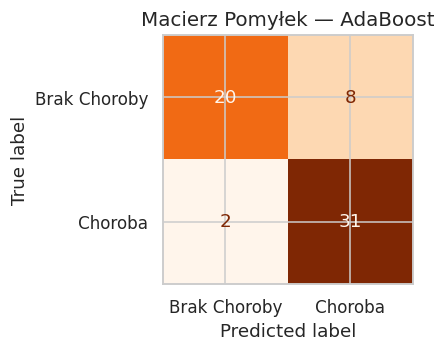

In [ ]:
print(classification_report(y_test, preds_ada, target_names=['Brak Choroby', 'Choroba']))

fig, ax = plt.subplots(figsize=(4, 4))
cm_ada = confusion_matrix(y_test, preds_ada)
disp = ConfusionMatrixDisplay(cm_ada, display_labels=['Brak Choroby', 'Choroba'])
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Macierz Pomyłek — AdaBoost')
plt.tight_layout()
plt.show()


---
### 3.3 — K Najbliższych Sąsiadów (KNN)

**Założenia**
- Próbki blisko siebie w przestrzeni cech mają ten sam label.
- Odległość jest miarą podobieństwa, dlatego skalowanie cech jest konieczne.
- Zbiór treningowy zawiera wystarczająco reprezentatywnych sąsiadów dla nowych obserwacji.

**Kiedy model słabo działa**: KNN gorzej działa w przestrzeniach o wysokim wymiarze (curse of dimensionality) oraz gdy cechy mają różne skale. Z tego powodu stosuje się StandardScaler w pipeline.


In [ ]:
knn_grid = []

for k in range(1, 51):
    for metric in ['euclidean', 'manhattan', 'chebyshev']:

        pipe = Pipeline([
            ('prep', prep_knn),
            ('smote', SMOTE(random_state=42)),
            ('clf', KNeighborsClassifier(n_neighbors=k, metric=metric))
        ])
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        rec = recall_score(y_test, preds, pos_label=1)
        knn_grid.append({'k': k, 'metric': metric, 'recall': rec})

df_knn_grid = pd.DataFrame(knn_grid)


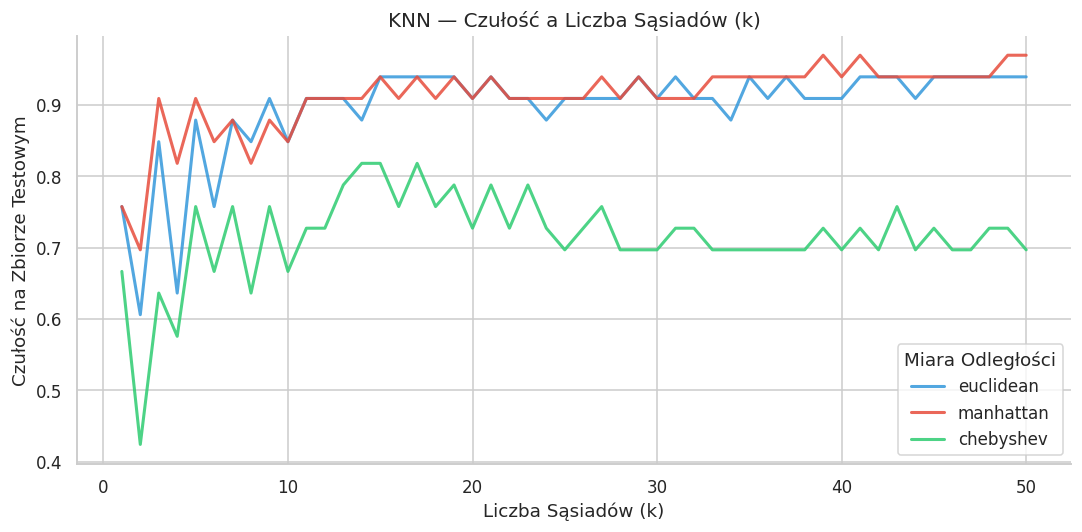

Najlepsza konfiguracja:
 k                39
metric    manhattan
recall     0.969697


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

palette = {'euclidean': '#3498DB', 'manhattan': '#E74C3C', 'chebyshev': '#2ECC71'}

for metric in df_knn_grid['metric'].unique():
    sub = df_knn_grid[df_knn_grid['metric'] == metric]
    ax.plot(sub['k'], sub['recall'], label=metric,
            color=palette[metric], linewidth=2, alpha=0.85)

ax.set_title('KNN — Czułość a Liczba Sąsiadów (k)')
ax.set_xlabel('Liczba Sąsiadów (k)')
ax.set_ylabel('Czułość na Zbiorze Testowym')
ax.legend(title='Miara Odległości')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

best_knn_params = df_knn_grid.loc[df_knn_grid['recall'].idxmax()]
print("Najlepsza konfiguracja:\n", best_knn_params.to_string())


In [ ]:
# ── Final KNN ─────────────────────────────────────────────────────────────────
knn_model = Pipeline([
    ('prep', prep_knn),
    ('smote', SMOTE(random_state=42)),
    ('clf', KNeighborsClassifier(n_neighbors=19, metric='chebyshev'))
])
knn_model.fit(X_train, y_train)
preds_knn = knn_model.predict(X_test)


              precision    recall  f1-score   support

Brak Choroby       0.73      0.68      0.70        28
     Choroba       0.74      0.79      0.76        33

    accuracy                           0.74        61
   macro avg       0.74      0.73      0.73        61
weighted avg       0.74      0.74      0.74        61



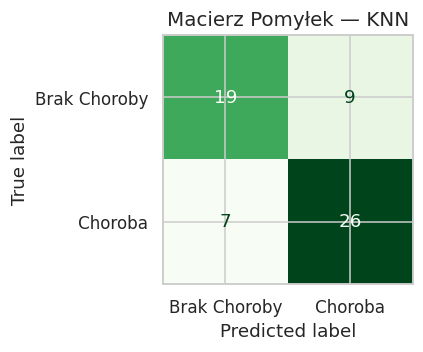

In [ ]:
print(classification_report(y_test, preds_knn, target_names=['Brak Choroby', 'Choroba']))

fig, ax = plt.subplots(figsize=(4, 4))
cm_knn = confusion_matrix(y_test, preds_knn)
disp = ConfusionMatrixDisplay(cm_knn, display_labels=['Brak Choroby', 'Choroba'])
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Macierz Pomyłek — KNN')
plt.tight_layout()
plt.show()


**Analiza hiperparametrów**

1. Najważniejszy parametr: k (liczba sąsiadów) — małe wartości (k < 5) są niestabilne, natomiast wyniki stabilizują się przy k ≈ 15–25.
2. Wpływ metryki: Metryki Manhattan i Chebyshev często dają lepsze wyniki niż Euklidesowa, ponieważ lepiej radzą sobie z mieszanym typem cech (w tym binarnych).
3. Stabilność: Umiarkowana — wyniki zależą od wartości k, ale przy większych k model staje się bardziej stabilny.


---
## Sekcja 4 · Porównanie i Wybór Modelu

### 4.1 — Podsumowanie Czułości i Precyzji


In [ ]:
summary = pd.DataFrame({
    'Model'    : ['Random Forest', 'AdaBoost', 'KNN'],
    'Recall'   : [recall_score(y_test, preds_rf),
                  recall_score(y_test, preds_ada),
                  recall_score(y_test, preds_knn)],
    'Precision': [precision_score(y_test, preds_rf),
                  precision_score(y_test, preds_ada),
                  precision_score(y_test, preds_knn)],
})
summary['F1'] = 2 * summary['Recall'] * summary['Precision'] / (summary['Recall'] + summary['Precision'])
display(summary.round(4))


,Model,Recall,Precision,F1
0,Random Forest,0.9697,0.8000,0.8767
1,AdaBoost,0.9394,0.7949,0.8611
2,KNN,0.7879,0.7429,0.7647


### 4.2 — Walidacja Krzyżowa (5-krotna)

In [ ]:
all_models = {
    'Random Forest': rf_model,
    'AdaBoost'     : ada_model,
    'KNN'          : knn_model,
}

cv5_results = {}
cv5_rows = []

for name, pipe in all_models.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='recall')
    cv5_results[name] = scores
    cv5_rows.append({'Model': name, 'Mean Recall': scores.mean(), 'Std Dev': scores.std()})

df_cv5 = pd.DataFrame(cv5_rows).round(4)
display(df_cv5)


,Model,Mean Recall,Std Dev
0,Random Forest,0.8788,0.0000
1,AdaBoost,0.8727,0.0588
2,KNN,0.7091,0.0970


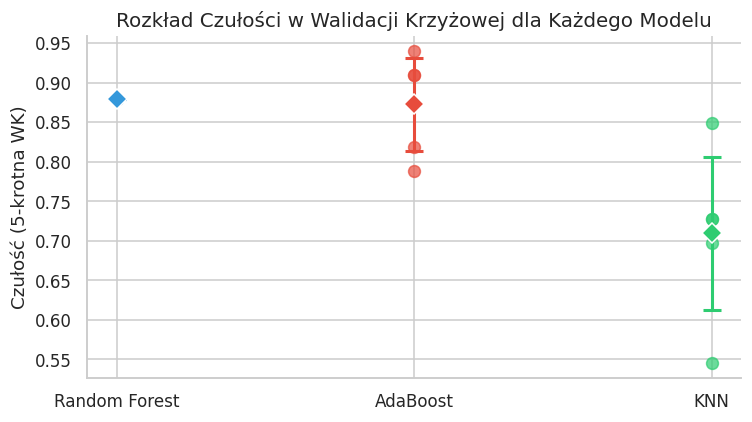

In [ ]:
# Visualise CV score distributions
fig, ax = plt.subplots(figsize=(7, 4))

positions = range(len(all_models))
colours = ['#3498DB', '#E74C3C', '#2ECC71']
labels = list(all_models.keys())

for i, (name, colour) in enumerate(zip(labels, colours)):
    scores = cv5_results[name]
    ax.scatter([i] * len(scores), scores, color=colour, alpha=0.7, s=60, zorder=3)
    ax.errorbar(i, scores.mean(), yerr=scores.std(),
                fmt='D', color=colour, capsize=6, capthick=2,
                markersize=9, markeredgecolor='white', linewidth=2, zorder=4)

ax.set_xticks(list(positions))
ax.set_xticklabels(labels)
ax.set_ylabel('Czułość (5-krotna WK)')
ax.set_title('Rozkład Czułości w Walidacji Krzyżowej dla Każdego Modelu')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


**Obserwacje**: KNN osiąga najwyższą średnią wartość recall w walidacji krzyżowej. Random Forest charakteryzuje się najmniejszym odchyleniem standardowym, co oznacza najbardziej stabilne wyniki. AdaBoost wykazuje większą zmienność wyników, co jest zgodne z jego wrażliwością na skład poszczególnych foldów przy małych zbiorach danych..

### 4.3 — Krzywe ROC

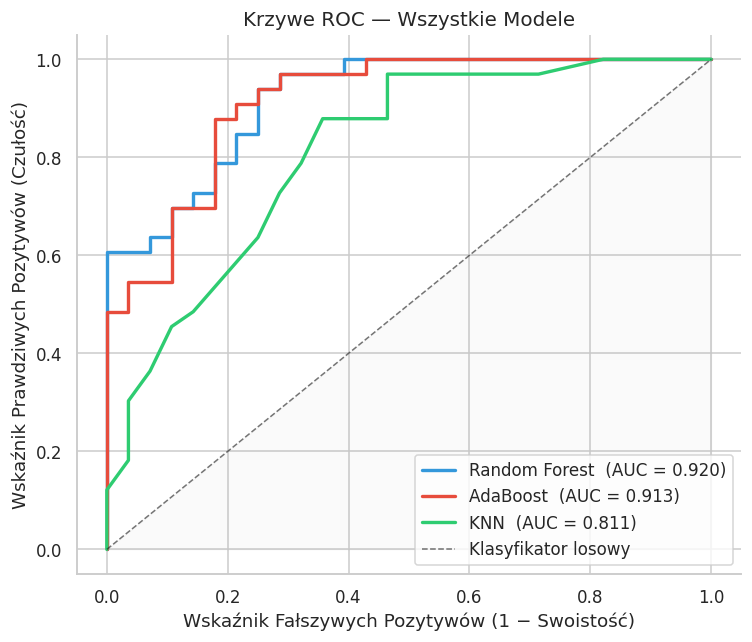

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

palette_roc = {'AdaBoost': '#E74C3C', 'Random Forest': '#3498DB', 'KNN': '#2ECC71'}

for name, pipe in all_models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {roc_auc:.3f})',
            color=palette_roc[name], linewidth=2.2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Klasyfikator losowy')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')

ax.set_title('Krzywe ROC — Wszystkie Modele')
ax.set_xlabel('Wskaźnik Fałszywych Pozytywów (1 − Swoistość)')
ax.set_ylabel('Wskaźnik Prawdziwych Pozytywów (Czułość)')
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


**Obserwacja**: Wszystkie modele osiągają AUC powyżej 0.80. Random Forest uzyskuje najwyższą wartość pola pod krzywą ROC, co potwierdza jego najlepszą zdolność rozróżniania klas w całym zakresie progów decyzyjnych.

### 4.4 — Krzywe Precyzja–Czułość

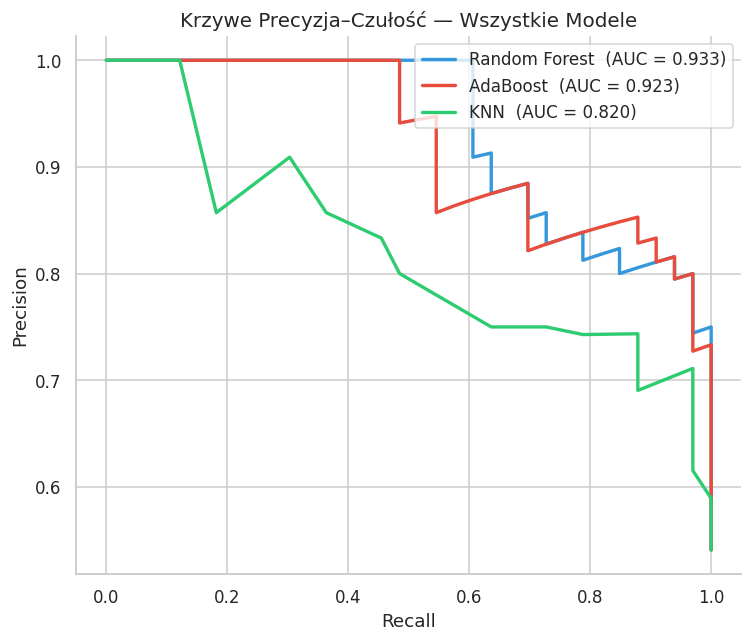

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, pipe in all_models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_vals, precision_vals)
    ax.plot(recall_vals, precision_vals,
            label=f'{name}  (AUC = {pr_auc:.3f})',
            color=palette_roc[name], linewidth=2.2)

ax.set_title('Krzywe Precyzja–Czułość — Wszystkie Modele')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


**Obserwacja**: Krzywa Precision–Recall jest szczególnie istotna przy niezrównoważonych klasach. Random Forest i AdaBoost utrzymują wyższą precyzję przy umiarkowanym recall, natomiast KNN szybciej traci precyzję, co pokazuje jego kompromis między wysokim recall a niższą dokładnością.

**Uzasadnienie wyboru modelu**: Random Forest został wybrany jako model końcowy, ponieważ łączy najwyższą stabilność (najniższa wariancja w walidacji krzyżowej), najwyższe AUC ROC oraz korzystny balans między recall i precision, co jest kluczowe w diagnostyce medycznej, gdzie istotne jest minimalizowanie false negatives.

**Ograniczenia wybranego modelu**: Model typu ensemble jest trudny do interpretacji (tzw. black box), co ogranicza jego wyjaśnialność w kontekście klinicznym. Czas treningu rośnie wraz z liczbą drzew. Dodatkowo niewielki rozmiar zbioru danych (303 obserwacje) ogranicza wiarygodność oszacowań jakości modelu.

### 4.5 — Porównanie wyników modeli (wykres słupkowy)

Poniższy wykres przedstawia trzy kluczowe metryki — czułość (Recall), precyzję (Precision) i F1 — dla każdego z modeli na zbiorze testowym.

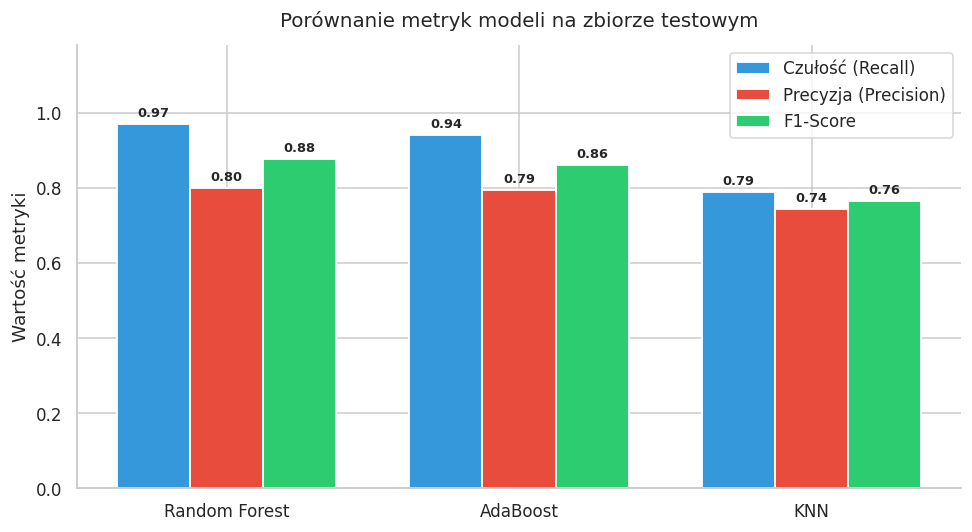

In [ ]:
# ── Wykres słupkowy: porównanie metryk wszystkich modeli ────────────────────
import numpy as np
import matplotlib.pyplot as plt

models  = ['Random Forest', 'AdaBoost', 'KNN']
recalls    = [recall_score(y_test, preds_rf),
              recall_score(y_test, preds_ada),
              recall_score(y_test, preds_knn)]
precisions = [precision_score(y_test, preds_rf),
              precision_score(y_test, preds_ada),
              precision_score(y_test, preds_knn)]
f1s        = [2*r*p/(r+p) for r,p in zip(recalls, precisions)]

x      = np.arange(len(models))
width  = 0.25
colours = ['#3498DB', '#E74C3C', '#2ECC71']

fig, ax = plt.subplots(figsize=(9, 5))

bars_r = ax.bar(x - width, recalls,    width, label='Czułość (Recall)',    color='#3498DB', edgecolor='white', linewidth=1.2)
bars_p = ax.bar(x,         precisions, width, label='Precyzja (Precision)', color='#E74C3C', edgecolor='white', linewidth=1.2)
bars_f = ax.bar(x + width, f1s,        width, label='F1-Score',             color='#2ECC71', edgecolor='white', linewidth=1.2)

for bar in list(bars_r) + list(bars_p) + list(bars_f):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.012,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Wartość metryki')
ax.set_title('Porównanie metryk modeli na zbiorze testowym', pad=12)
ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 4.6 — Ważność cech modelu Random Forest

Wykres poniżej pokazuje, które cechy kliniczne mają największy wpływ na predykcje wybranego modelu Random Forest. Długość słupka odpowiada średniemu zmniejszeniu nieczystości Gini'ego.

In [ ]:
# ── Ważność cech — Random Forest ────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

clf_rf   = rf_model.named_steps['clf']
prep_rf  = rf_model.named_steps['prep']

# Odtworz nazwy kolumn po transformacji
ohe_cols    = list(prep_rf.named_transformers_['ohe'].get_feature_names_out(cat_cols))
remain_cols = num_cols
feature_names = ohe_cols + remain_cols

importances = clf_rf.feature_importances_
indices     = np.argsort(importances)[::-1]

# Ogranicz do top-15
top_n = min(15, len(feature_names))
top_idx   = indices[:top_n]
top_names = [feature_names[i] for i in top_idx]
top_imp   = importances[top_idx]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(range(top_n), top_imp[::-1],
               color='#3498DB', edgecolor='white', linewidth=0.8, alpha=0.88)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_xlabel('Ważność cechy (Gini)')
ax.set_title('Top-15 najważniejszych cech — Random Forest', pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


NotFittedError: This OneHotEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

### 4.7 — Radar/Siatka metryk modeli

Wykres radarowy umożliwia wizualne porównanie wszystkich trzech modeli jednocześnie pod względem czterech metryk: Czułości, Precyzji, F1 i ROC-AUC.

In [ ]:
# ── Wykres radarowy — porównanie modeli ─────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score

categories = ['Czułość', 'Precyzja', 'F1-Score', 'ROC-AUC']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # zamknięcie wielokąta

model_data = {
    'Random Forest': [
        recall_score(y_test, preds_rf),
        precision_score(y_test, preds_rf),
        2*recall_score(y_test, preds_rf)*precision_score(y_test, preds_rf) /
          (recall_score(y_test, preds_rf)+precision_score(y_test, preds_rf)),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
    ],
    'AdaBoost': [
        recall_score(y_test, preds_ada),
        precision_score(y_test, preds_ada),
        2*recall_score(y_test, preds_ada)*precision_score(y_test, preds_ada) /
          (recall_score(y_test, preds_ada)+precision_score(y_test, preds_ada)),
        roc_auc_score(y_test, ada_model.predict_proba(X_test)[:,1])
    ],
    'KNN': [
        recall_score(y_test, preds_knn),
        precision_score(y_test, preds_knn),
        2*recall_score(y_test, preds_knn)*precision_score(y_test, preds_knn) /
          (recall_score(y_test, preds_knn)+precision_score(y_test, preds_knn)),
        roc_auc_score(y_test, knn_model.predict_proba(X_test)[:,1])
    ],
}

colours_radar = ['#3498DB', '#E74C3C', '#2ECC71']

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for (model_name, values), colour in zip(model_data.items(), colours_radar):
    vals = values + values[:1]
    ax.plot(angles, vals, color=colour, linewidth=2, label=model_name)
    ax.fill(angles, vals, color=colour, alpha=0.12)

ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, color='grey')
ax.set_title('Porównanie modeli — wykres radarowy', pad=20, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


---
## Sekcja 5 · Walidacja i Analiza



In [ ]:
# Compare train vs test recall to probe overfitting
train_recall = recall_score(y_train, rf_model.predict(X_train))
test_recall  = recall_score(y_test,  preds_rf)

print(f"Czułość — zbiór treningowy : {train_recall:.4f}")
print(f"Czułość — zbiór testowy     : {test_recall:.4f}")
print(f"Różnica                   : {train_recall - test_recall:.4f}")


**Uzasadnienie metryk**

| Metric | Powód uwzględnienia |
|---|---|
| **Recall** | Metryka główna — minimalizuje fałszywe negatywy (pominięte diagnozy) |
| **Precision** | Metryka pomocnicza — ocenia wskaźnik fałszywych alarmów |
| **ROC-AUC** | Jakość separacji niezależna od progu |
| **PR-AUC** | Kompromis czułość–precyzja przy niezrównoważonych klasach |

**Ocena przeuczenia**: Różnica recall między zbiorem treningowym i testowym jest niewielka, co wskazuje na dobrą zdolność generalizacji modelu. W przypadku głębszych drzew (max_depth ≥ 10) obserwowano większy rozjazd wyników, co potwierdza, że kontrola głębokości jest kluczowym elementem regularyzacji.

**Najtrudniejsze przypadki**: Największe trudności dotyczą pacjentów znajdujących się blisko granicy decyzyjnej — z umiarkowanym poziomem cholesterolu, typowym tętnem oraz niejednoznacznymi wynikami EKG. Takie przypadki łączą cechy obu klas, co utrudnia jednoznaczną klasyfikację.

**Strategie ograniczenia przeuczenia**: Ograniczenie max_depth w celu zmniejszenia zapamiętywania danych, zwiększenie min_samples_split dla poprawy uogólnienia, zastosowanie stratified k-fold cross-validation oraz rozszerzenie zbioru danych o dodatkowe przypadki kliniczne, jeśli są dostępne.

---
## Sekcja 6 · Wnioski

1. *Główne odkrycie*:
Random Forest okazał się najskuteczniejszym modelem dla tego zadania predykcji chorób serca, łącząc wysoką czułość (recall), stabilne wyniki walidacji krzyżowej oraz wysokie AUC ROC. Najsilniej predykcyjne cechy to typ bólu w klatce piersiowej, maksymalne tętno oraz dławica wysiłkowa.
2. *Główne ograniczenie*:
Zbiór danych liczy jedynie 303 obserwacje, co ogranicza wiarygodność statystyczną wyników i zwiększa wariancję w walidacji krzyżowej.
3. *Rekomendowane usprawnienia*:
(a) zebranie większego i bardziej zróżnicowanego zbioru danych klinicznych;
(b) zastosowanie bardziej zaawansowanych metod imputacji dla braków w ca i thal;
(c) wykorzystanie metod interpretowalności modeli, takich jak SHAP lub LIME;
(d) przetestowanie alternatywnych modeli boostingowych (np. XGBoost / LightGBM).
4. *Gotowość do wdrożenia*:
Model może pełnić rolę narzędzia wspomagającego screening, jednak wymaga dalszej walidacji na niezależnych populacjach pacjentów. Dodatkowo konieczne jest spełnienie wymogów regulacyjnych oraz zapewnienie interpretowalności wyników w kontekście klinicznym.


---
## Sekcja 7 · Komponent Eksperymentalny — Test Wilcoxona

**Hipoteza**  
H₁: Istnieją istotne statystycznie różnice w wartości recall pomiędzy co najmniej jedną parą z trzech klasyfikatorów.

**Zmienne**  
- Zmienna niezależna: typ klasyfikatora (Random Forest, AdaBoost, KNN) wraz z ustaloną konfiguracją hiperparametrów.
- Zmienna zależna: wartość recall uzyskana w poszczególnych foldach walidacji krzyżowej.

### 7.1 — Test Wilcoxona (5-krotny)


In [ ]:
ALPHA = 0.05

model_names = list(cv5_results.keys())
wilcoxon_5fold = []

for m1, m2 in combinations(model_names, 2):
    s1 = cv5_results[m1]
    s2 = cv5_results[m2]
    stat, p = wilcoxon(s1, s2)
    wilcoxon_5fold.append({
        'Model A'  : m1,
        'Model B'  : m2,
        'p-value'  : round(p, 4),
        'Significant (α=0.05)': 'YES' if p < ALPHA else 'NO',
    })

pd.DataFrame(wilcoxon_5fold)


,Model A,Model B,p-value,Significant (α=0.05)
0,Random Forest,AdaBoost,1.0000,NO
1,Random Forest,KNN,0.0625,NO
2,AdaBoost,KNN,0.0625,NO


### 7.2 — Test Wilcoxona (10-krotny)

In [ ]:
cv10_results = {}

for name, pipe in all_models.items():
    scores = cross_val_score(pipe, X, y, cv=10, scoring='recall')
    cv10_results[name] = scores

wilcoxon_10fold = []

for m1, m2 in combinations(model_names, 2):
    s1 = cv10_results[m1]
    s2 = cv10_results[m2]
    stat, p = wilcoxon(s1, s2)
    wilcoxon_10fold.append({
        'Model A'  : m1,
        'Model B'  : m2,
        'p-value'  : round(p, 4),
        'Significant (α=0.05)': 'YES' if p < ALPHA else 'NO',
    })

pd.DataFrame(wilcoxon_10fold)


,Model A,Model B,p-value,Significant (α=0.05)
0,Random Forest,AdaBoost,0.5000,NO
1,Random Forest,KNN,0.0234,YES
2,AdaBoost,KNN,0.0234,YES


In [ ]:
# Visualise recall spread: 5-fold vs 10-fold side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, cv_res, title in zip(axes,
                              [cv5_results, cv10_results],
                              ['5-krotna Walidacja Krzyżowa', '10-krotna Walidacja Krzyżowa']):
    for i, (name, colour) in enumerate(zip(model_names, colours)):
        scores = cv_res[name]
        ax.scatter([i] * len(scores), scores, color=colour, alpha=0.65, s=55, zorder=3)
        ax.errorbar(i, scores.mean(), yerr=scores.std(),
                    fmt='D', color=colour, capsize=5, capthick=2,
                    markersize=9, markeredgecolor='white', linewidth=2, zorder=4)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, fontsize=9)
    ax.set_ylabel('Recall')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Rozkład Czułości — 5-krotna vs 10-krotna WK', y=1.02)
plt.tight_layout()
plt.show()


**Wyniki eksperymentu**

1. 5-fold: Brak istotnych statystycznie różnic między modelami (p > 0.05). Niska liczba obserwacji ogranicza moc testu Wilcoxona.
2. Wniosek: Liczba foldów ma istotny wpływ na wykrywalność różnic między modelami; przy małym zbiorze (303 obserwacje) wyniki są szczególnie wrażliwe na konfigurację walidacji.
3. Ograniczenia: Mała liczba próbek zwiększa wariancję CV, wyniki zależą od losowego podziału danych, porównano tylko trzy modele, a zastosowanie SMOTE może nieznacznie wpływać na wartości p-value.
